## 04_histogram.ipynb

In [152]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [153]:
db_path = "../data/checking-logs.sqlite"
conn = sqlite3.connect(db_path)

## Analyze only the users, not the admins.

In [154]:
query = """
        SELECT
        timestamp
        FROM checker
        WHERE uid LIKE 'user_%'
        """

df = pd.read_sql(query, conn)

In [155]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

df['hour'] = df['timestamp'].dt.hour
df['is_weekend'] = df['timestamp'].dt.weekday >= 5

print('Working day:', (~df['is_weekend']).sum())
print('Weekend:',  df['is_weekend'].sum())

Working day: 2037
Weekend: 1170


## Create two lists of values for the histogram input: one for working days and one for weekends.

In [156]:
wd_hours = df[~df['is_weekend']]['hour'].tolist()
we_hours = df[df['is_weekend']]['hour'].tolist()

## Create a graph

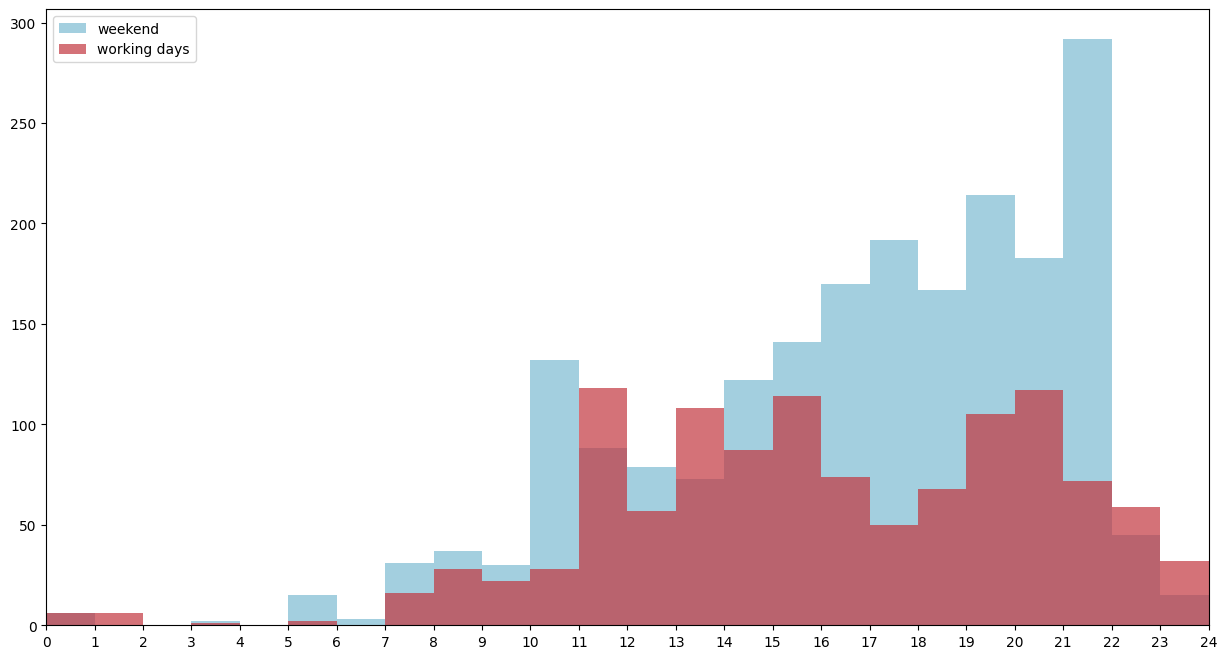

In [157]:
plt.figure(figsize = (15, 8))

plt.hist(
    [we_hours, wd_hours],
    bins=24,
    range=(0, 24),
    color=['#C3363F', '#7DBBD2'],
    alpha=0.7,
    label=['working days', 'weekend'],
    histtype='stepfilled',
)

plt.legend()
plt.xticks(range(0, 25))
plt.xlim(0, 24)
plt.show()

In [158]:
conn.close()

## "Are there hours when the total number of commits was higher on weekends than on working days?" In your answer, include the top four examples.

In [172]:
top_hours = (
    df.groupby(['hour', 'is_weekend'])
      .size()
      .unstack(fill_value=0)
      .rename(columns={False: 'working_day', True: 'weekend'})
      .query('weekend > working_day')
      .nlargest(4, 'weekend')
      .index.get_level_values('hour')
      .tolist()
)

print(top_hours)

[11, 13, 22, 23]
